# Naive GAN

**Load and Preprocess**
- Loading Data
- Normalizing pixel values : [0,255] -> [0,1] -> [-1,1]

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def load_data(batch_size=64):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
    ])
    
    train_dataset = datasets.MNIST(
        root='./data', 
        train=True, 
        transform=transform,
        download = True
    )
    
    dataloader = DataLoader(
        dataset=train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        drop_last=True 
    )
    
    return dataloader

**helper function** that we use to plot images (used both for training data visualization and generated data)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import torch

def plot_images(images, num_cols, title):

    if isinstance(images, torch.Tensor):
        images = [img for img in images]
        
    num_images = len(images)
    if num_images == 0:
        print("No images to plot.")
        return
        
    num_rows = math.ceil(num_images / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols, num_rows))
    if title:
        fig.suptitle(title, fontsize=16)
    

    if num_rows == 1 and num_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < num_images:

            normalized_img = images[i].detach().cpu().squeeze()
            
            unnormalized_img = (normalized_img + 1) / 2 
            
            unnormalized_img = torch.clamp(unnormalized_img, 0, 1)
            
            ax.imshow(unnormalized_img, cmap='gray')
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

**sanity check**

Batch image shape: torch.Size([64, 1, 28, 28])
Value range: Min = -1.0, Max = 1.0


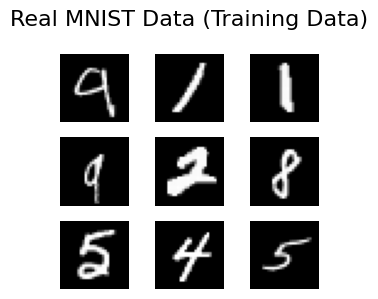

In [3]:
dataloader = load_data(batch_size=64)
real_images, labels = next(iter(dataloader))

print(f"Batch image shape: {real_images.shape}") 
print(f"Value range: Min = {real_images.min().item()}, Max = {real_images.max().item()}")


plot_images(real_images[:9] , 3, "Real MNIST Data (Training Data)")

**Generator Architecture**

In [4]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100, h=64, channels=1):
        super(Generator, self).__init__()
        
        self.net = nn.Sequential(

            nn.ConvTranspose2d(latent_dim, h * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(h * 4, h * 2, 3, 2, 1, bias=False),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(h * 2, h, 4, 2, 1, bias=False),
            nn.BatchNorm2d(h),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(h, channels, 4, 2, 1, bias=False),

            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.net(x)

**Discriminator Architecture**

In [5]:
class Discriminator(nn.Module):
    def __init__(self, h=64, channels=1):
        super(Discriminator, self).__init__()
        
        self.net = nn.Sequential(
            
            nn.Conv2d(channels, h, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(h, h * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(h * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(h * 2, h * 4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(h * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(h * 4, 1, 4, 1, 0, bias=False),
        )
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        output = self.net(x)
        output = output.view(-1, 1)
        return self.sigmoid(output)


**Weight Initialization**

drawing weights from a normal distribution with a mean of 0 and a standard deviation of 0.02 for Conv layers and mean 1 , std 0.02 for BatchNorm

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


**Instance & sanity check**

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
netG = Generator(latent_dim=latent_dim).to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), 

**Configs**

In [8]:
import torch.optim as optim

criterion = nn.BCELoss()

real_label = 1.0
fake_label = 0.0


lr = 0.0002
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

G_losses = []
D_losses = []

**Training Loop**

epoch [1/30][0/937]Loss_D: 1.6283 Loss_G: 1.5486 D(x): 0.6641 D(G(z)): Before Updating G 0.6639 /  After Updating D 0.2380
epoch [1/30][500/937]Loss_D: 0.1136 Loss_G: 2.9658 D(x): 0.9262 D(G(z)): Before Updating G 0.0315 /  After Updating D 0.0629
epoch 1 generated images: 


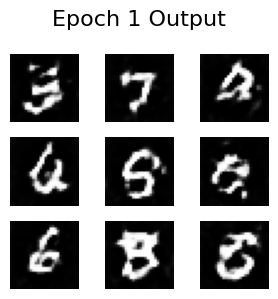

epoch [2/30][0/937]Loss_D: 0.2273 Loss_G: 2.7459 D(x): 0.9117 D(G(z)): Before Updating G 0.1169 /  After Updating D 0.0801
epoch [2/30][500/937]Loss_D: 0.3357 Loss_G: 3.0531 D(x): 0.9213 D(G(z)): Before Updating G 0.2074 /  After Updating D 0.0584
epoch [3/30][0/937]Loss_D: 0.3041 Loss_G: 3.1089 D(x): 0.9319 D(G(z)): Before Updating G 0.1922 /  After Updating D 0.0583
epoch [3/30][500/937]Loss_D: 0.4859 Loss_G: 2.0346 D(x): 0.7691 D(G(z)): Before Updating G 0.1717 /  After Updating D 0.1612
epoch [4/30][0/937]Loss_D: 0.3976 Loss_G: 1.9758 D(x): 0.7132 D(G(z)): Before Updating G 0.0275 /  After Updating D 0.1803
epoch [4/30][500/937]Loss_D: 0.7096 Loss_G: 3.1439 D(x): 0.9157 D(G(z)): Before Updating G 0.4225 /  After Updating D 0.0575
epoch [5/30][0/937]Loss_D: 0.1804 Loss_G: 3.4875 D(x): 0.8989 D(G(z)): Before Updating G 0.0618 /  After Updating D 0.0476
epoch [5/30][500/937]Loss_D: 0.4981 Loss_G: 4.0994 D(x): 0.9672 D(G(z)): Before Updating G 0.3205 /  After Updating D 0.0240
epoch [6

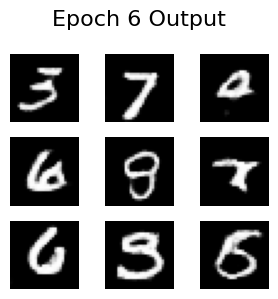

epoch [7/30][0/937]Loss_D: 0.6687 Loss_G: 1.6817 D(x): 0.6409 D(G(z)): Before Updating G 0.1283 /  After Updating D 0.2295
epoch [7/30][500/937]Loss_D: 0.2575 Loss_G: 3.6719 D(x): 0.9649 D(G(z)): Before Updating G 0.1848 /  After Updating D 0.0344
epoch [8/30][0/937]Loss_D: 0.2653 Loss_G: 3.2852 D(x): 0.8626 D(G(z)): Before Updating G 0.0956 /  After Updating D 0.0506
epoch [8/30][500/937]Loss_D: 0.1447 Loss_G: 3.1807 D(x): 0.9610 D(G(z)): Before Updating G 0.0939 /  After Updating D 0.0576
epoch [9/30][0/937]Loss_D: 0.1706 Loss_G: 3.3148 D(x): 0.9441 D(G(z)): Before Updating G 0.0993 /  After Updating D 0.0480
epoch [9/30][500/937]Loss_D: 0.7519 Loss_G: 2.7925 D(x): 0.8256 D(G(z)): Before Updating G 0.3577 /  After Updating D 0.0908
epoch [10/30][0/937]Loss_D: 0.0594 Loss_G: 3.8375 D(x): 0.9622 D(G(z)): Before Updating G 0.0194 /  After Updating D 0.0328
epoch [10/30][500/937]Loss_D: 1.2764 Loss_G: 4.9419 D(x): 0.9910 D(G(z)): Before Updating G 0.6657 /  After Updating D 0.0105
epoch 

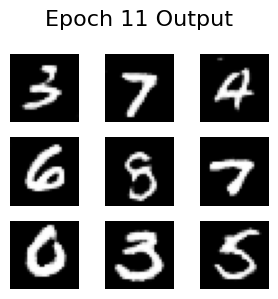

epoch [12/30][0/937]Loss_D: 0.4008 Loss_G: 1.3877 D(x): 0.7613 D(G(z)): Before Updating G 0.0927 /  After Updating D 0.3160
epoch [12/30][500/937]Loss_D: 0.1411 Loss_G: 3.9848 D(x): 0.9218 D(G(z)): Before Updating G 0.0519 /  After Updating D 0.0316
epoch [13/30][0/937]Loss_D: 0.1650 Loss_G: 3.8673 D(x): 0.9498 D(G(z)): Before Updating G 0.0995 /  After Updating D 0.0350
epoch [13/30][500/937]Loss_D: 0.1875 Loss_G: 3.7696 D(x): 0.9835 D(G(z)): Before Updating G 0.1466 /  After Updating D 0.0316
epoch [14/30][0/937]Loss_D: 0.3042 Loss_G: 2.9793 D(x): 0.9586 D(G(z)): Before Updating G 0.2052 /  After Updating D 0.0740
epoch [14/30][500/937]Loss_D: 0.0689 Loss_G: 4.3951 D(x): 0.9701 D(G(z)): Before Updating G 0.0364 /  After Updating D 0.0204
epoch [15/30][0/937]Loss_D: 0.1232 Loss_G: 4.0837 D(x): 0.9532 D(G(z)): Before Updating G 0.0685 /  After Updating D 0.0281
epoch [15/30][500/937]Loss_D: 0.4671 Loss_G: 1.1878 D(x): 0.7427 D(G(z)): Before Updating G 0.0986 /  After Updating D 0.3850


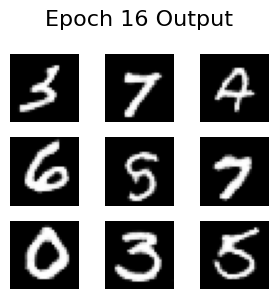

epoch [17/30][0/937]Loss_D: 1.3304 Loss_G: 7.0819 D(x): 0.9962 D(G(z)): Before Updating G 0.6517 /  After Updating D 0.0016
epoch [17/30][500/937]Loss_D: 0.0828 Loss_G: 3.7157 D(x): 0.9765 D(G(z)): Before Updating G 0.0553 /  After Updating D 0.0389
epoch [18/30][0/937]Loss_D: 0.1958 Loss_G: 3.4065 D(x): 0.9132 D(G(z)): Before Updating G 0.0830 /  After Updating D 0.0603
epoch [18/30][500/937]Loss_D: 0.0461 Loss_G: 4.2679 D(x): 0.9863 D(G(z)): Before Updating G 0.0310 /  After Updating D 0.0248
epoch [19/30][0/937]Loss_D: 1.0924 Loss_G: 2.3733 D(x): 0.4127 D(G(z)): Before Updating G 0.0012 /  After Updating D 0.1664
epoch [19/30][500/937]Loss_D: 0.2455 Loss_G: 2.8077 D(x): 0.9210 D(G(z)): Before Updating G 0.1337 /  After Updating D 0.0826
epoch [20/30][0/937]Loss_D: 0.1354 Loss_G: 3.4499 D(x): 0.9947 D(G(z)): Before Updating G 0.1135 /  After Updating D 0.0432
epoch [20/30][500/937]Loss_D: 0.1314 Loss_G: 3.1727 D(x): 0.9156 D(G(z)): Before Updating G 0.0339 /  After Updating D 0.0655


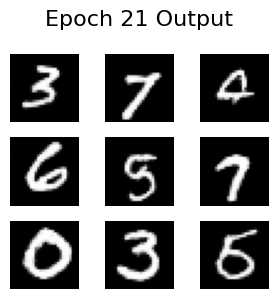

epoch [22/30][0/937]Loss_D: 0.1491 Loss_G: 3.6321 D(x): 0.8946 D(G(z)): Before Updating G 0.0300 /  After Updating D 0.0381
epoch [22/30][500/937]Loss_D: 0.1029 Loss_G: 4.6983 D(x): 0.9773 D(G(z)): Before Updating G 0.0743 /  After Updating D 0.0134
epoch [23/30][0/937]Loss_D: 0.2998 Loss_G: 3.0834 D(x): 0.8657 D(G(z)): Before Updating G 0.1195 /  After Updating D 0.0704
epoch [23/30][500/937]Loss_D: 0.3517 Loss_G: 2.2481 D(x): 0.7997 D(G(z)): Before Updating G 0.0997 /  After Updating D 0.1515
epoch [24/30][0/937]Loss_D: 0.1762 Loss_G: 4.1802 D(x): 0.9737 D(G(z)): Before Updating G 0.1284 /  After Updating D 0.0220
epoch [24/30][500/937]Loss_D: 0.2816 Loss_G: 3.7644 D(x): 0.9814 D(G(z)): Before Updating G 0.1960 /  After Updating D 0.0335
epoch [25/30][0/937]Loss_D: 0.6140 Loss_G: 2.9919 D(x): 0.9558 D(G(z)): Before Updating G 0.3923 /  After Updating D 0.0671
epoch [25/30][500/937]Loss_D: 0.2438 Loss_G: 2.6109 D(x): 0.8307 D(G(z)): Before Updating G 0.0378 /  After Updating D 0.1224


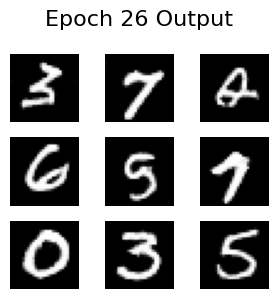

epoch [27/30][0/937]Loss_D: 0.1626 Loss_G: 3.1235 D(x): 0.8991 D(G(z)): Before Updating G 0.0459 /  After Updating D 0.0731
epoch [27/30][500/937]Loss_D: 0.1354 Loss_G: 4.6836 D(x): 0.9205 D(G(z)): Before Updating G 0.0439 /  After Updating D 0.0162
epoch [28/30][0/937]Loss_D: 0.2952 Loss_G: 2.9133 D(x): 0.8370 D(G(z)): Before Updating G 0.0899 /  After Updating D 0.0856
epoch [28/30][500/937]Loss_D: 0.0715 Loss_G: 4.3116 D(x): 0.9525 D(G(z)): Before Updating G 0.0184 /  After Updating D 0.0210
epoch [29/30][0/937]Loss_D: 0.0306 Loss_G: 4.0676 D(x): 0.9911 D(G(z)): Before Updating G 0.0211 /  After Updating D 0.0267
epoch [29/30][500/937]Loss_D: 0.4657 Loss_G: 3.6313 D(x): 0.6649 D(G(z)): Before Updating G 0.0041 /  After Updating D 0.0465
epoch [30/30][0/937]Loss_D: 0.1653 Loss_G: 4.1311 D(x): 0.9588 D(G(z)): Before Updating G 0.1085 /  After Updating D 0.0250
epoch [30/30][500/937]Loss_D: 0.1337 Loss_G: 3.9340 D(x): 0.9773 D(G(z)): Before Updating G 0.0973 /  After Updating D 0.0283


In [9]:
num_epochs = 30

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        
        # D Network
        netD.zero_grad()
        
        real = data[0].to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        
        output = netD(real).view(-1)
        D_loss_real = criterion(output, label)
        D_loss_real.backward()
        D_x = output.mean().item()

        random_noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        
        fake_images = netG(random_noise)
        label.fill_(fake_label)
        
        output = netD(fake_images.detach()).view(-1)
        D_loss_fake = criterion(output, label)
        D_loss_fake.backward()
        D_G_before_G_update = output.mean().item()
        
        D_total_loss = D_loss_real + D_loss_fake
        optimizerD.step()

        # G Network
        netG.zero_grad()
        label.fill_(real_label)
        
        output = netD(fake_images).view(-1)
        G_loss = criterion(output, label)
        G_loss.backward()
        D_G_after_D_update = output.mean().item()
        
        optimizerG.step()

        if i % 500 == 0:
            print(f'epoch [{epoch + 1}/{num_epochs}][{i}/{len(dataloader)}]'
                  f'Loss_D: {D_total_loss.item():.4f} Loss_G: {G_loss.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): Before Updating G {D_G_before_G_update:.4f} /  After Updating D {D_G_after_D_update:.4f}')
        
        G_losses.append(G_loss.item())
        D_losses.append(D_total_loss.item())
        
    with torch.no_grad():
        fake_display = netG(fixed_noise).detach().cpu()
    
    if epoch % 5 == 0:
        print(f'epoch {epoch + 1} generated images: ')
        plot_images(fake_display[:9], num_cols=3, title=f"Epoch {epoch + 1} Output")

torch.save(netG.state_dict(), 'naive_gan_generator.pth')
torch.save(netD.state_dict(), 'naive_gan_discriminator.pth')
print("Models saved.")

**Analysis**

- loss Discriminator much lower than loss Generator and by D(x) we undertand that discriminator is stronger than generator. Still, gradient didn't vanish and generator updates.
- visually, the results are acceptable. Also we have a good mixture of numbers so mode collapase hasn't occured

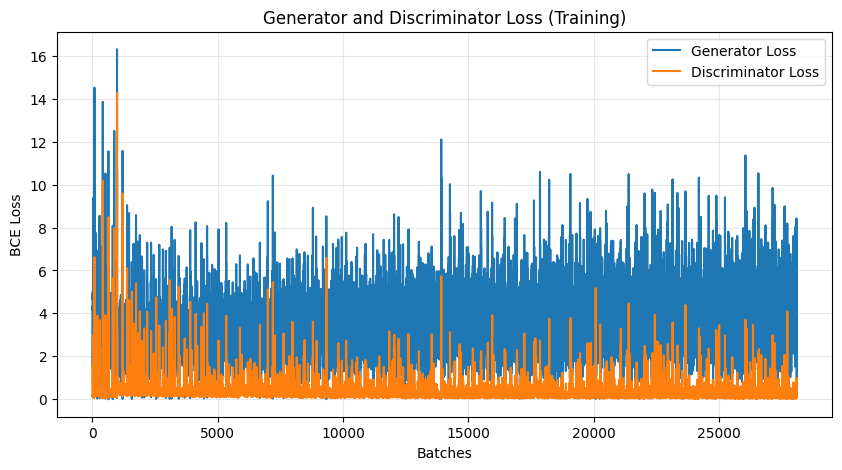

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss (Training)")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Batches")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

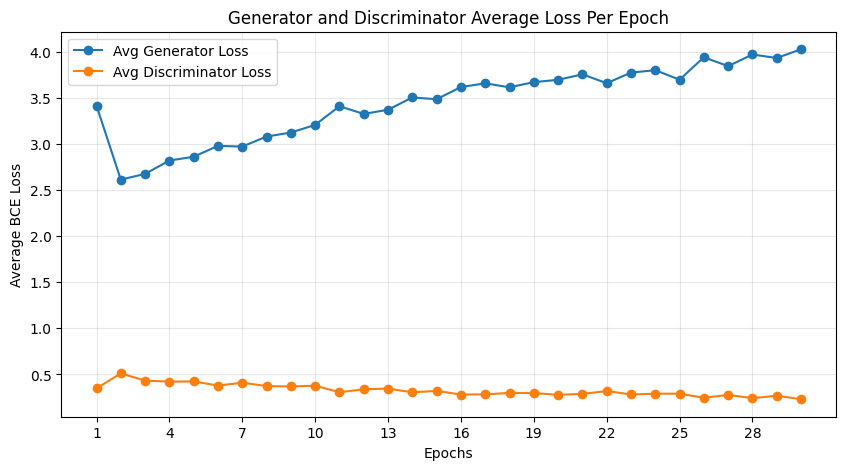

In [20]:
import numpy as np
import matplotlib.pyplot as plt

num_epochs = len(G_losses) // len(dataloader)

G_losses_epoch = np.array(G_losses[:num_epochs * len(dataloader)]).reshape(num_epochs, len(dataloader)).mean(axis=1)
D_losses_epoch = np.array(D_losses[:num_epochs * len(dataloader)]).reshape(num_epochs, len(dataloader)).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Average Loss Per Epoch")
plt.plot(range(1, num_epochs + 1), G_losses_epoch, label="Avg Generator Loss", color='#1f77b4', marker='o')
plt.plot(range(1, num_epochs + 1), D_losses_epoch, label="Avg Discriminator Loss", color='#ff7f0e', marker='o')

plt.xlabel("Epochs")
plt.ylabel("Average BCE Loss")
plt.xticks(range(1, num_epochs + 1, max(1, num_epochs // 10)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

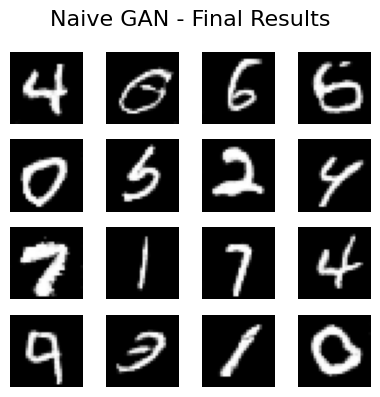

In [17]:
netG.eval() 

with torch.no_grad():
    final_noise = torch.randn(16, latent_dim, 1, 1, device=device)
    final_fakes = netG(final_noise)

plot_images(final_fakes, num_cols=4, title="Naive GAN - Final Results")

In [12]:
!pip install torch-fidelity
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm
!pip install torch-fidelity
import math

def calculate_fid(generator, dataloader, device, num_samples=1000):

    print(f"Calculating FID over {num_samples} samples...")
    
    fid = FrechetInceptionDistance(feature=2048).to(device)
    generator.eval()
    
    samples_processed = 0
    expected_batches = math.ceil(num_samples / 64)

    for real_batch, _ in tqdm(dataloader, desc="Extracting Features", total=expected_batches):
        if samples_processed >= num_samples:
            break
            
        b_size = real_batch.size(0)
        
        real_images = ((real_batch + 1) / 2 * 255).byte().to(device)

        real_images = real_images.repeat(1, 3, 1, 1)
        
        with torch.no_grad():
            noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_batch = generator(noise)
            
        fake_images = ((fake_batch + 1) / 2 * 255).byte().to(device)
        fake_images = fake_images.repeat(1, 3, 1, 1)
        
        fid.update(real_images, real=True)
        fid.update(fake_images, real=False)
        
        samples_processed += b_size
        
    fid_score = fid.compute().item()
    print(f"\nFinal FID Score: {fid_score:.4f}")
    
    fid.reset() 
    return fid_score

naive_gan_fid = calculate_fid(netG, dataloader, device, num_samples=10000)

Calculating FID over 10000 samples...


Extracting Features: 100%|██████████| 157/157 [01:14<00:00,  2.11it/s]



Final FID Score: 5.9782
